# AG-HYPOPT · Trial 07

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Campaign state at trial_07. Six trials recorded:

- trial_01 = target, h_f 5.349, h_s 7.652 -> 0.0837.
- trial_02 = sim, h_f 5.308, h_s 3.060 -> 0.1249.
- trial_03 = power, h_f 8.658, h_s 4.220 -> 0.1541.
- trial_04 = target, h_f 9.821, h_s 2.920 -> 0.0926.
- trial_05 = target, h_f 3.580, h_s 5.784 -> 0.0818 (current best).
- trial_06 = target, h_f 3.678, h_s 5.319 -> 0.0890.

Ranking: target rule from 0.0818 to 0.0926, sim 0.1249, power 0.1541; exp6 reference target h_f 4.0 ->
0.0803. The target-rule points with h_f in [3.5, 5.4] all sit in 0.080-0.089 with SE 0.021-0.024, i.e.
a plateau indistinguishable within noise. The high side (h_f -> 10) clearly degrades; the low side
(h_f near the 1.0 floor) has not been explored.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_07'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (6/5 trials)
ID |     ei | params
 1 | 0.7276 | {"bandwidth_rule": "sim", "h_f_scale": 5.1143327045904385, "h_s_scale": 4.30182913402348}
 2 | 1.3733 | {"bandwidth_rule": "power", "h_f_scale": 10.033512602210429, "h_s_scale": 7.091175237405616}
 3 | 2.2814 | {"bandwidth_rule": "target", "h_f_scale": 3.8035654641953704, "h_s_scale": 5.756262173917019}
 4 | 1.4363 | {"bandwidth_rule": "target", "h_f_scale": 4.957171394351384, "h_s_scale": 4.542977550750438}
 5 | 0.3542 | {"bandwidth_rule": "target", "h_f_scale": 7.737935647003338, "h_s_scale": 1.3924830665095576}
 6 | 2.2856 | {"bandwidth_rule": "target", "h_f_scale": 3.0882711595688317, "h_s_scale": 5.893506297969663}
 7 | 2.7251 | {"bandwidth_rule": "target", "h_f_scale": 1.1297342809675643, "h_s_scale": 8.61235332970023}
 8 | 3.4740 | {"bandwidth_rule": "target", "h_f_scale": 3.5499492154491654, "h_s_scale": 7.124513228023323}
 9 |      - | {"bandwidth_rule": "sim", "h_f_scale": 10.683653693789115, "h_s_scale": 6.60769

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

The single most useful fact is that the target rule is flat/noise-limited for h_f in [3.5, 5.4], so a
further trial inside that plateau (e.g. #8 target 3.55/7.13 or #3 3.80/5.76) would mostly re-sample noise.
The informative thing to map now is where the plateau ENDS. The upper edge is known (h_f ~9.8 -> 0.0926, 
worse); the lower edge is completely untested - no trial has gone below h_f = 3.58.

Candidate #7 is a target configuration at h_f 1.130, i.e. just above the 1.0 floor, far below anything
tested. It is the only proposal that brackets the low end of the target rule and so can locate the turnover
on that side. Its EI (2.725) is the second-highest among target candidates and higher than most - the
optimizer also treats that region as under-explored. The remaining candidates are either inside the known
plateau (#3, #8), on the losing rules (#1 sim, #2 power, #9 sim), or at high h_f already shown to degrade
(#5, #10).

I choose candidate 7 (target, h_f_scale 1.130, h_s_scale 8.612).


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 7            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'bandwidth_rule': 'target', 'h_f_scale': 1.1297342809675643, 'h_s_scale': 8.61235332970023}
Running  1nW Trans05 ... 

μ 9.39 -> 10.07 | γ 8.5 -> 3.87 | NLL 1.22


Running  1nW Trans20 ... 

μ 17.32 -> 47.25 | γ 8.5 -> 6.44 | NLL 2.59


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 76.32 | γ 14.1 -> 14.34 | NLL 1.90


Running 3nW Trans100 ... 

μ 175.71 -> 104.55 | γ 14.1 -> 13.84 | NLL 1.97



Total: 7.7 min


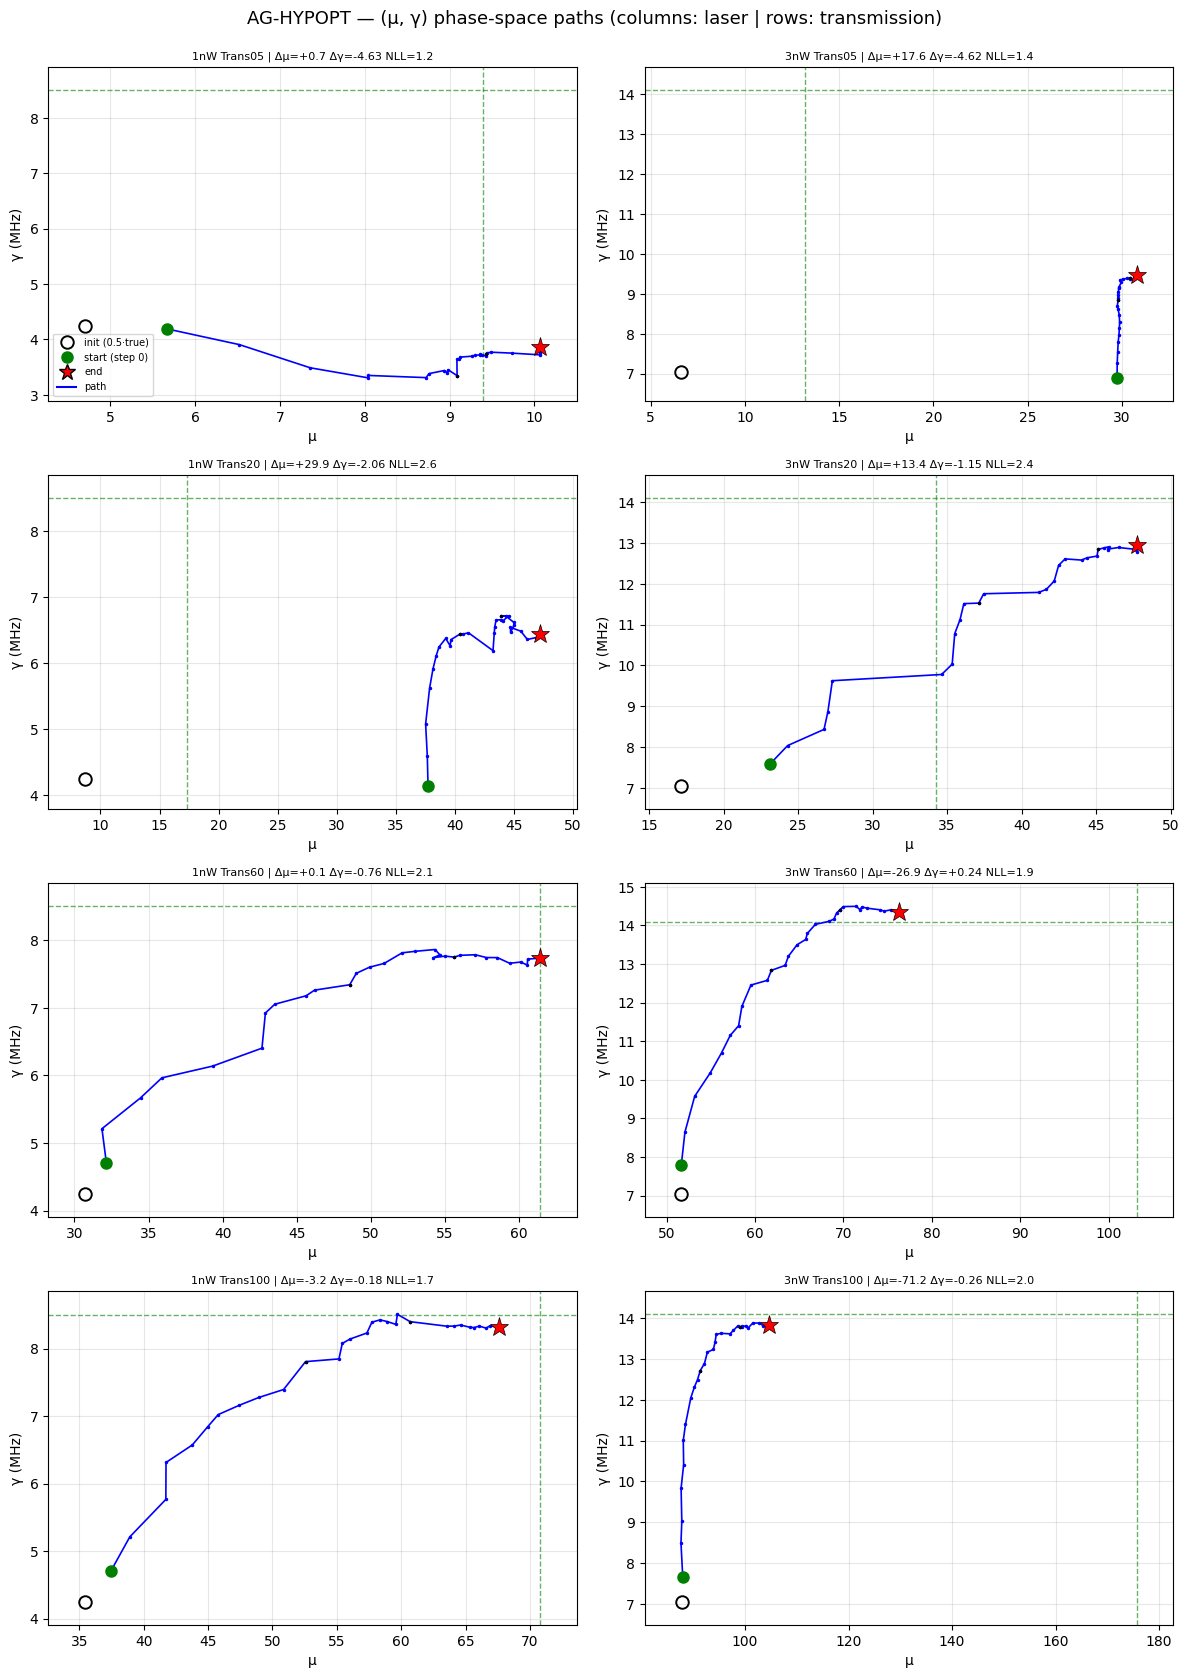

trial finished in 7.7 min
objective = 0.1165 ± 0.0827
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.07    +7.2 |     8.50    3.87   -54.5
1nW Trans20       17.32   47.25  +172.9 |     8.50    6.44   -24.2
1nW Trans60       61.37   61.44    +0.1 |     8.50    7.74    -9.0
1nW Trans100       70.82   67.60    -4.5 |     8.50    8.32    -2.1
3nW Trans05       13.20   30.80  +133.3 |    14.10    9.48   -32.7
3nW Trans20       34.28   47.72   +39.2 |    14.10   12.95    -8.2
3nW Trans60      103.20   76.32   -26.0 |    14.10   14.34    +1.7
3nW Trans100      175.71  104.55   -40.5 |    14.10   13.84    -1.8

weighted objective (T-graded, cap=1.0) = 0.1165 | diverged cells: 0
μ: RMSE 29.964 (rel 80.3%, bias -4.942) | γ: RMSE 2.476 (rel 24.4%, bias -1.676)


TypeError: unsupported operand type(s) for -: 'str' and 'str'

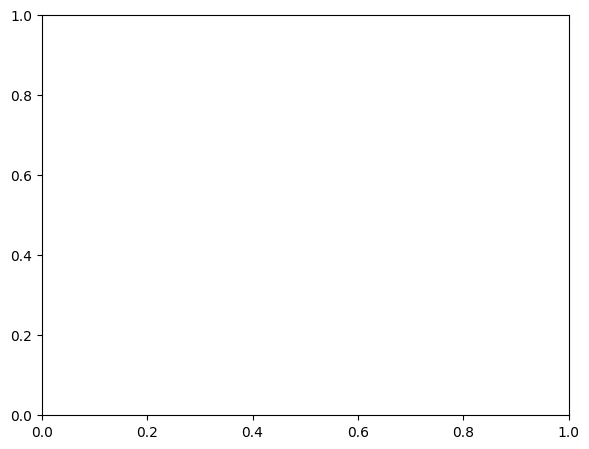

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Objective = 0.1165 ± 0.0827, gamma finite on all 8 cells, diverged cells: 0. Config: bandwidth_rule =
target, h_f_scale = 1.130, h_s_scale = 8.612 - the low-h_f edge of the target rule, well below every
previous trial.

This degrades the target rule, and it fails through MU this time: mu explodes on the low-count cells
(1nW Trans20 47.25 vs 17.32, +172.9 %; 3nW Trans05 30.80 vs 13.20, +133.3 %; 3nW Trans20 +39.2 %) while
the high-transmission cells are essentially fine (1nW Trans60 +0.1 %, 1nW Trans100 -4.5 %). gamma behaves
moderately (overestimated slightly at 3nW Trans60 +1.7 %, underestimated elsewhere). The large SE
(±0.0827) comes from the two wildly-off low-T cells.

This closes the bracket on the target rule. Combining all target trials: 0.0803 @ h_f 4.0 (exp6), 0.0818 @
3.58, 0.0837 @ 5.35, 0.0890 @ 3.68, 0.0926 @ 9.82, 0.1165 @ 1.13. The objective is low and noise-flat in
the middle band (h_f ~3.5-5.5) and rises on BOTH edges - sharply below (~0.116 at h_f 1.13, via mu
overshoot in low-count cells) and moderately above (~0.093 at h_f 9.82). So the target-rule optimum is a
plateau centred near h_f ~4, which is exactly where exp6 froze its default.

Execution note: same trailing `plot_parallel` diagnostic TypeError; objective computed and printed first,
so the trial stands. No rerun.

**Summary:** Trial 7 (target rule, h_f 1.130, h_s 8.612) scores objective 0.1165 ± 0.0827, worse than the target plateau, failing via a mu overshoot up to +172.9 % on the low-count cells.
**Key insight:** The target-rule optimum is now bracketed on both sides (worse at h_f 1.13 and at h_f 9.82, flat-best around h_f 3.5-5.5), so exp6's frozen h_f=4.0 is essentially the target-rule optimum.

Notes for Anuar (optional, not acted on): both edges of the target plateau fail via the low-count cells
(mu blow-up), reinforcing that the residual objective is a low-count-cell model issue (FM#8) rather than a
tuning one.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 7 (target rule, h_f 1.130, h_s 8.612) scores objective 0.1165 ± 0.0827, worse than the target plateau, failing via a mu overshoot up to +172.9 % on the low-count cells."      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The target-rule optimum is now bracketed on both sides (worse at h_f 1.13 and at h_f 9.82, flat-best around h_f 3.5-5.5), so exp6's frozen h_f=4.0 is essentially the target-rule optimum."  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_07 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_08.ipynb. Open it and follow its cells from the top.
